In [1]:
# Importing required libraries for data analysis and visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Displaying available SQL Server drivers

import pyodbc

print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client 11.0', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [3]:
# Creating connection between Python and SQL Server

connection = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=ASHIS\\MSSQL;'
    'DATABASE=IPL_Analysis;'
    'Trusted_Connection=yes;'
)

print("SQL Server connected successfully!")

SQL Server connected successfully!


In [4]:
#Loading IPL matches data into pandas dataframe
query = "select * from matches"
df = pd.read_sql(query,connection)

print("IPL Data loaded Successfully!")

IPL Data loaded Successfully!


C:\Users\Ashis kumar\AppData\Local\Temp\ipykernel_7532\2575768395.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,connection)


In [5]:
# Displaying first 5 rows of IPL dataset
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,223,20,False,NA,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,False,NA,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20,False,NA,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5,166,20,False,NA,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,False,NA,BF Bowden,K Hariharan


In [6]:
# =====================================
# DATA CLEANING AND PREPROCESSING
# =====================================

# Standardize team names
df['winner'] = df['winner'].replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

df['team1'] = df['team1'].replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

df['team2'] = df['team2'].replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

# Fill missing city values
df.loc[(df['city']=='NA') &
       (df['venue']=='Dubai International Cricket Stadium'),
       'city'] = 'Dubai'

df.loc[(df['city']=='NA') &
       (df['venue']=='Sharjah Cricket Stadium'),
       'city'] = 'Sharjah'


In [7]:
# Checking total number of rows and columns in dataset
df.shape

(1095, 20)

In [8]:
# Displaying dataset information and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               1095 non-null   int64 
 1   season           1095 non-null   str   
 2   city             1095 non-null   str   
 3   date             1095 non-null   object
 4   match_type       1095 non-null   str   
 5   player_of_match  1095 non-null   str   
 6   venue            1095 non-null   str   
 7   team1            1095 non-null   str   
 8   team2            1095 non-null   str   
 9   toss_winner      1095 non-null   str   
 10  toss_decision    1095 non-null   str   
 11  winner           1095 non-null   str   
 12  result           1095 non-null   str   
 13  result_margin    1095 non-null   str   
 14  target_runs      1095 non-null   str   
 15  target_overs     1095 non-null   str   
 16  super_over       1095 non-null   bool  
 17  method           1095 non-null   str   
 18 

In [9]:
# Analyzing top winning IPL teams
top_teams = df['winner'].value_counts().head(10)

top_teams

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Name: count, dtype: int64

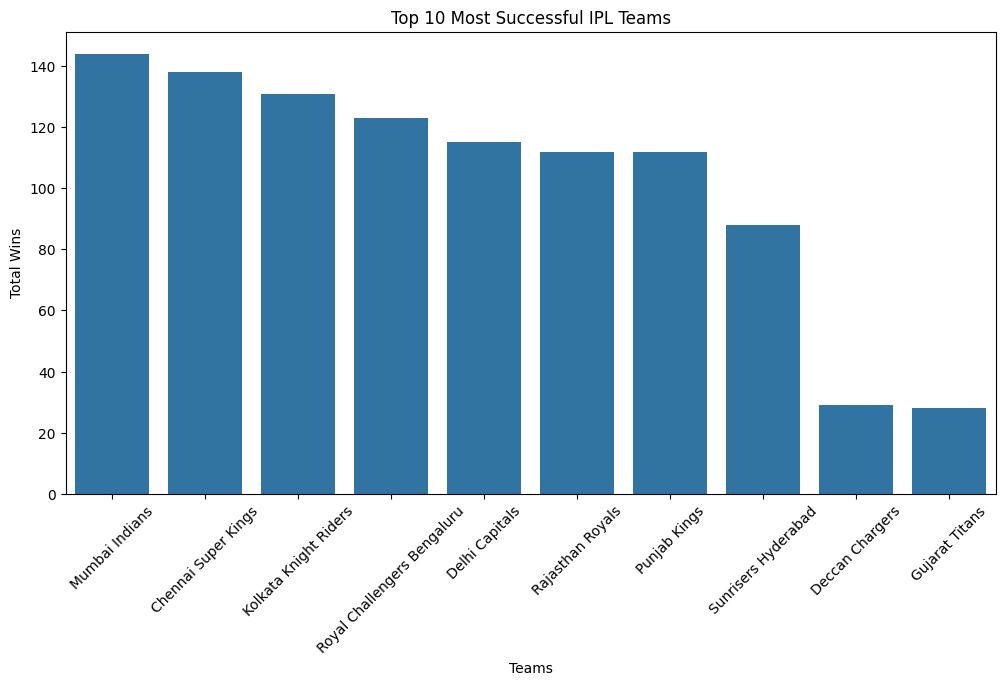

In [10]:
# Creating bar chart for top winning IPL teams
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_teams.index,
    y=top_teams.values
)

plt.title("Top 10 Most Successful IPL Teams")
plt.xlabel("Teams")
plt.ylabel("Total Wins")

plt.xticks(rotation=45)

plt.show()

### Insight

Mumbai Indians and Chennai Super Kings have secured the highest number of wins in IPL history. Their consistent performances across multiple seasons have established them as the most dominant franchises in the tournament.

In [11]:
# Analyzing toss decision preferences in IPL
toss_decision = df['toss_decision'].value_counts()

toss_decision

toss_decision
field    704
bat      391
Name: count, dtype: int64

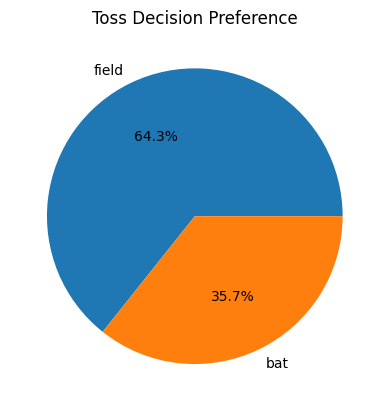

In [12]:
# Creating pie chart for toss decision analysis
plt.Figure(figsize=(6,6))

plt.pie(
    toss_decision.values,
    labels=toss_decision.index,
    autopct='%1.1f%%'
)
plt.title("Toss Decision Preference")

plt.show()

### Insight

The majority of IPL teams prefer to field first after winning the toss. This suggests that teams generally favor chasing targets due to factors such as dew conditions, pitch behavior, and better match awareness.

In [13]:
# Analyzing players with the highest Player of the Match awards
top_players = df['player_of_match'].value_counts().head(10)
top_players

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
SP Narine         15
Name: count, dtype: int64

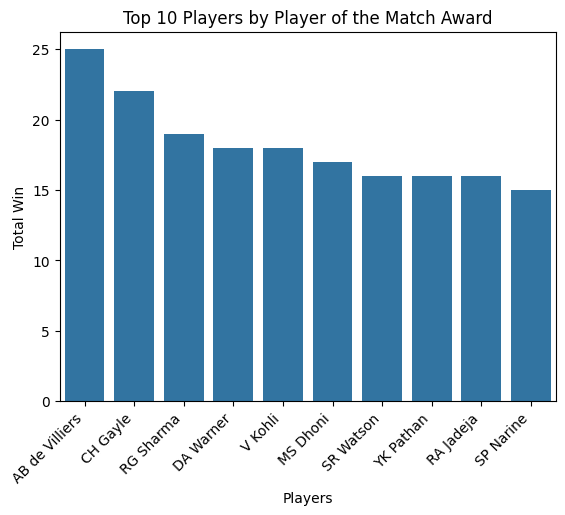

In [14]:
# Creating bar chart for top players based on Player of the Match awards
plt.Figure(figsize=(12,6))

sns.barplot(
    x=top_players.index,
    y=top_players.values
)

plt.title("Top 10 Players by Player of the Match Award")
plt.xlabel("Players")
plt.ylabel("Total Win")

plt.xticks(rotation=45,ha='right')

plt.show()

### Insight

AB de Villiers has won the highest number of Player of the Match awards, highlighting his ability to deliver match-winning performances. Other players such as Chris Gayle, Rohit Sharma, David Warner, and Virat Kohli have also made significant contributions throughout IPL history.

In [15]:
# Calculating total IPL matches played in each season
season_matches = df['season'].value_counts().sort_index()
season_matches

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64

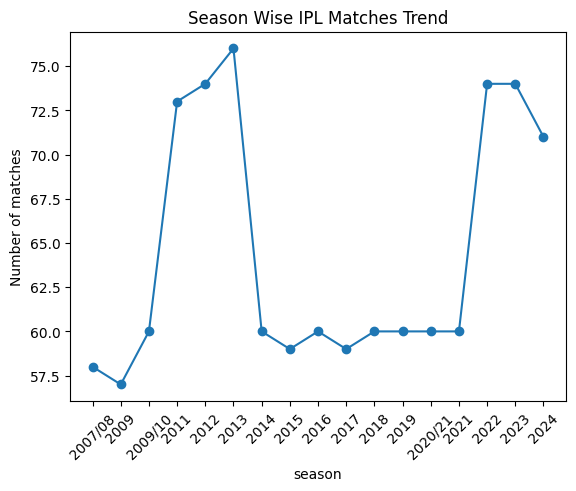

In [16]:
# Creating line chart to analyze season-wise IPL match trends
plt.Figure(figsize=(12,6))

plt.plot(
    season_matches.index,
    season_matches.values,
    marker='o'
)

plt.title("Season Wise IPL Matches Trend")
plt.xlabel('season')
plt.ylabel("Number of matches")

plt.xticks(rotation=45)

plt.show()

### Insight

The number of IPL matches has generally increased over the years due to tournament expansion and the addition of new franchises. This reflects the growing popularity and scale of the IPL.

In [17]:
# Top stadiums hosting IPL matches
top_venues = df['venue'].value_counts().head(10)
top_venues

venue
Wankhede Stadium                              118
M Chinnaswamy Stadium                          94
Eden Gardens                                   93
MA Chidambaram Stadium                         85
Rajiv Gandhi International Stadium             77
Punjab Cricket Association Stadium, Mohali     61
Feroz Shah Kotla                               60
Sawai Mansingh Stadium                         57
Dubai International Cricket Stadium            46
Dr DY Patil Sports Academy                     37
Name: count, dtype: int64

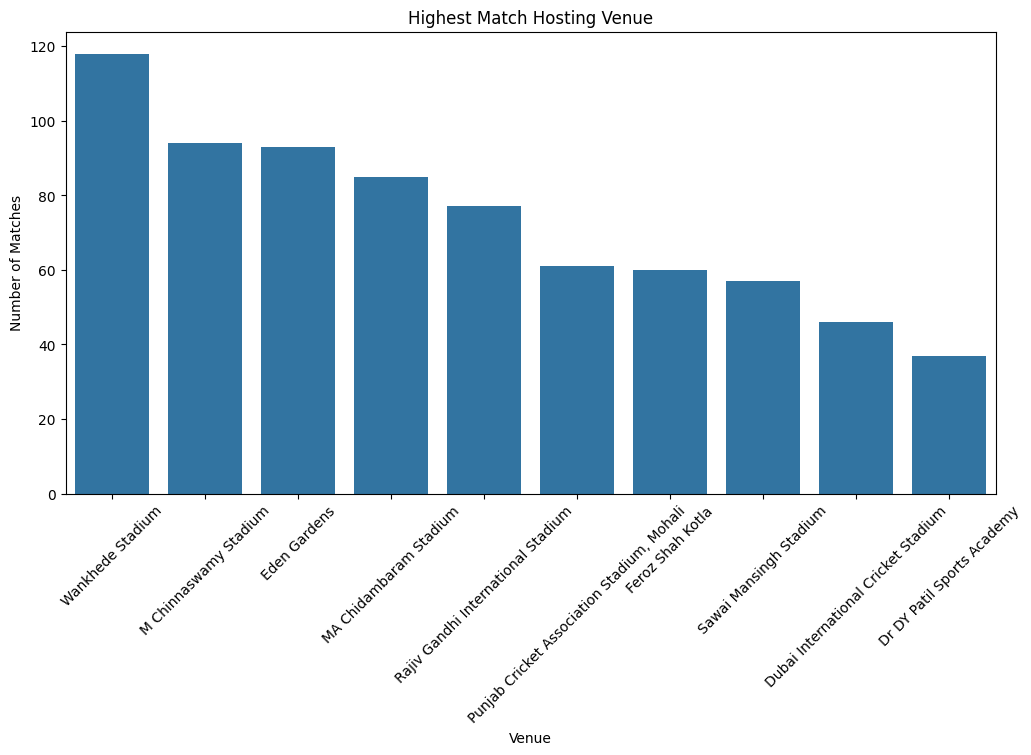

In [18]:
# Creating Bar chart to analys Which Venue Hosting the Most of the Meaches
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_venues.index,
    y=top_venues.values,
)

plt.title("Highest Match Hosting Venue")
plt.xlabel('Venue')
plt.ylabel('Number of Matches')

plt.xticks(rotation=45)
plt.show()

### Insight

Wankhede Stadium, M. Chinnaswamy Stadium, and Eden Gardens have hosted the highest number of IPL matches. These venues have played a crucial role in IPL history and regularly host important fixtures.

In [19]:
# Calculating matches where toss winner also won the match
toss_match_win = df[df['toss_winner'] == df['winner']]
toss_match_win.shape[0]

421

In [20]:
toss_win_persentage = (
    toss_match_win.shape[0] / df.shape[0]
)*100
print(round(toss_win_persentage, 2))

38.45


In [21]:
result_type = df['result'].value_counts()
result_type

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

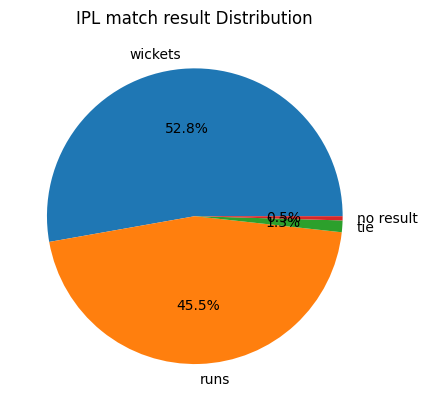

In [22]:
# Creating pie chart to analyze IPL match result distribution
plt.Figure(figsize=(12,12))

plt.pie(
    result_type.values,
    labels=result_type.index,
    autopct='%1.1f%%'
)
plt.title("IPL match result Distribution")
plt.show()

### Insight

Most IPL matches are decided by either wickets or runs, while ties and no-result matches are relatively uncommon. This indicates that IPL matches typically produce clear and competitive outcomes.

In [23]:
#Match own by Chasing team
chasing_wins = df[df['result'] == 'wickets']
top_chasing_teams = chasing_wins['winner'].value_counts().head(10)
top_chasing_teams

winner
Kolkata Knight Riders          76
Mumbai Indians                 71
Rajasthan Royals               67
Chennai Super Kings            67
Delhi Capitals                 66
Royal Challengers Bengaluru    64
Punjab Kings                   58
Sunrisers Hyderabad            43
Gujarat Titans                 17
Gujarat Lions                  12
Name: count, dtype: int64

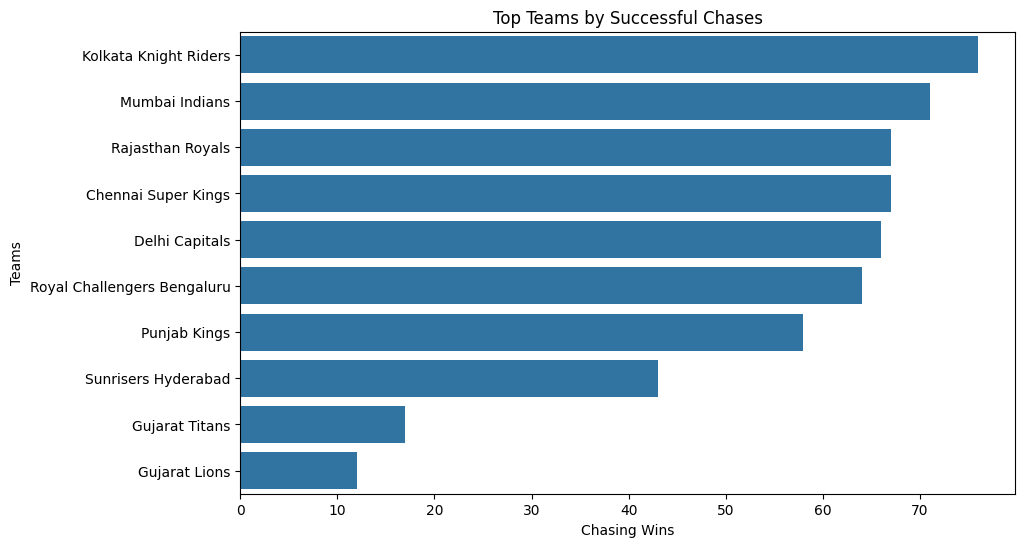

In [24]:
#Visualizing top teams with the highest number of successful chases
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_chasing_teams.values,
    y=top_chasing_teams.index
)

plt.title("Top Teams by Successful Chases")
plt.xlabel("Chasing Wins")
plt.ylabel("Teams")

plt.show()

### Insight

The analysis suggests that teams batting second have often enjoyed a higher success rate. This highlights the strategic advantage of chasing targets in T20 cricket.

In [25]:
# Analyzing Super Over matches
super_over_matches = df['super_over'].value_counts()
super_over_matches

super_over
False    1081
True       14
Name: count, dtype: int64

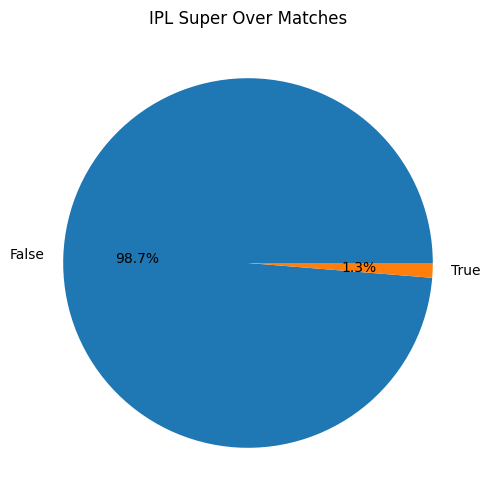

In [26]:
#Creating pie chart for Super Over Matches
plt.figure(figsize=(6,6))

plt.pie(
    super_over_matches.values,
    labels=super_over_matches.index,
    autopct='%1.1f%%'
)

plt.title("IPL Super Over Matches")
plt.show()

### Insight

Super Over matches are extremely rare in IPL history, occurring only 14 times. This demonstrates that tied matches are uncommon despite the highly competitive nature of the tournament.

In [27]:
#Top cities Hosting IPL matches
top_cities = df['city'].value_counts().head(10)
top_cities

city
Mumbai        173
Kolkata        93
Delhi          90
Chennai        85
Hyderabad      77
Bangalore      65
Chandigarh     61
Jaipur         57
Pune           51
Dubai          46
Name: count, dtype: int64

In [28]:
#Searching which venue city name showing 'NA'
df[df['city'] == 'NA'][['city','venue']].head(20)

,city,venue


In [29]:
#Filling missing City value
df.loc[
    (df['city'] == 'NA') &
    (df['venue'] == 'Dubai International Cricket Stadium'),
    'city'
]= 'Dubai'

df.loc[
    (df['city'] == 'NA') &
    (df['venue'] == 'Sharjah Cricket Stadium'),
    'city'
]= 'Sharjah'

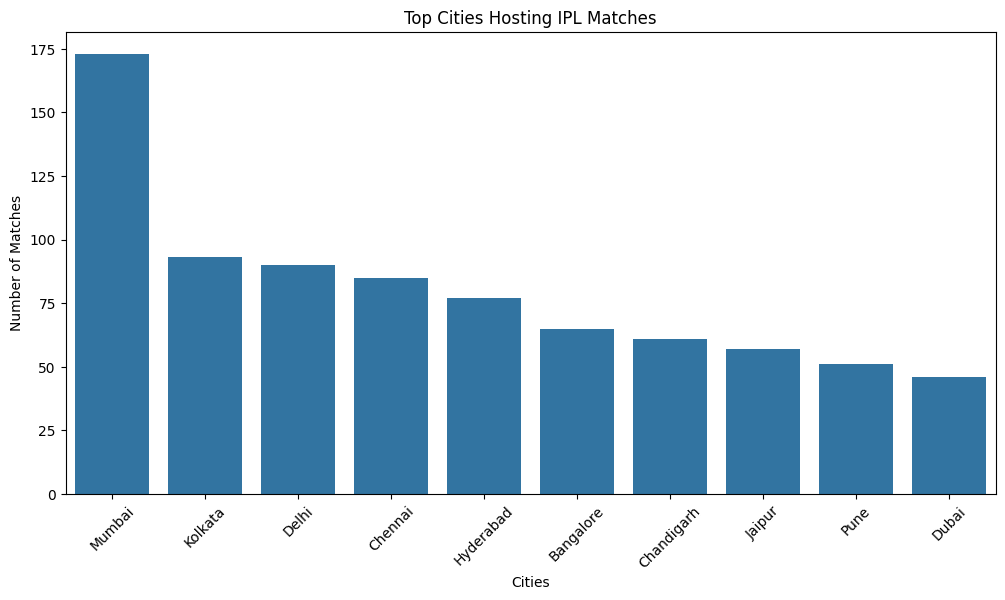

In [30]:
#create a bar chart for Top Cities Hosting IPL Matches
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
)

plt.title("Top Cities Hosting IPL Matches")
plt.xlabel('Cities')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.show()

### Insight

Mumbai, Bengaluru, Kolkata, Chennai, and Hyderabad have hosted a large number of IPL matches. These cities represent major cricket centers and are home to some of the league's most successful franchises.

In [31]:
team1_matches = df['team1'].value_counts()

team1_matches.head()

team1
Royal Challengers Bengaluru    144
Chennai Super Kings            128
Delhi Capitals                 126
Punjab Kings                   123
Mumbai Indians                 123
Name: count, dtype: int64

In [32]:
team2_matches = df['team2'].value_counts()

team2_matches.head()

team2
Mumbai Indians           138
Kolkata Knight Riders    130
Delhi Capitals           126
Punjab Kings             123
Rajasthan Royals         120
Name: count, dtype: int64

In [33]:
# Total matches played by each team

team1_matches = df['team1'].value_counts()
team2_matches = df['team2'].value_counts()

total_matches_played = team1_matches.add(team2_matches, fill_value=0)

total_matches_played.sort_values(ascending=False).head(15)

team1
Mumbai Indians                 261
Royal Challengers Bengaluru    255
Delhi Capitals                 252
Kolkata Knight Riders          251
Punjab Kings                   246
Chennai Super Kings            238
Rajasthan Royals               221
Sunrisers Hyderabad            182
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Titans                  45
Lucknow Super Giants            44
Gujarat Lions                   30
Rising Pune Supergiants         30
Kochi Tuskers Kerala            14
Name: count, dtype: int64

In [34]:
#Total win by each Team
top_win = df['winner'].value_counts()
top_win

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
No Result                        5
Name: count, dtype: int64

In [35]:
#Calculating win persentage of the team
win_percentage = (
    top_win / total_matches_played
) * 100

top_win_percentage = win_percentage.sort_values(ascending=False).head(10)
top_win_percentage

winner
Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Rising Pune Supergiants        50.000000
Sunrisers Hyderabad            48.351648
Royal Challengers Bengaluru    48.235294
Delhi Capitals                 45.634921
Name: count, dtype: float64

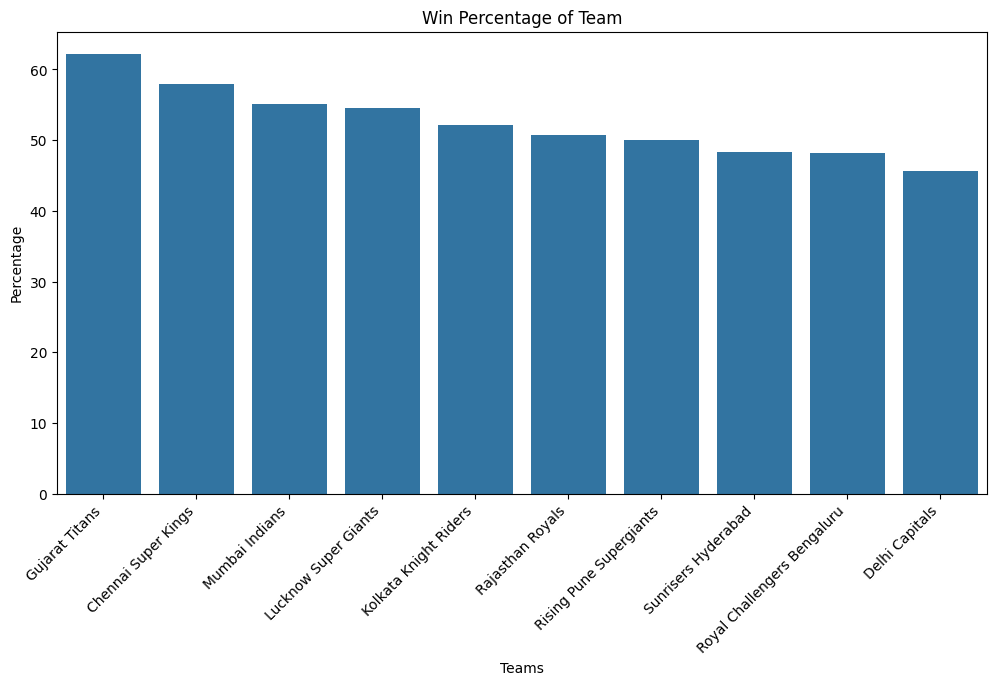

In [36]:
#creating a bar chart for Win percentage of the Team
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_win_percentage.index,
    y=top_win_percentage.values,
)

plt.title("Win Percentage of Team")
plt.xlabel('Teams')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.show()

### Insight

Gujarat Titans have the highest winning percentage among IPL teams. However, Chennai Super Kings and Mumbai Indians have maintained strong winning percentages over a much larger number of matches, demonstrating long-term consistency.

In [37]:
df['match_type'].value_counts()

match_type
League                1029
Final                   17
Qualifier 1             14
Qualifier 2             14
Eliminator              11
Semi Final               6
Elimination Final        3
3rd Place Play-Off       1
Name: count, dtype: int64

In [38]:
#Filtering only IPL Final Matches
final_matches = df[df['match_type'] == 'Final']
final_matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
57,336040,2007/08,Mumbai,2008-06-01,Final,YK Pathan,Dr DY Patil Sports Academy,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3,164,20,False,NA,BF Bowden,RE Koertzen
114,392239,2009,Johannesburg,2009-05-24,Final,A Kumble,New Wanderers Stadium,Royal Challengers Bengaluru,Deccan Chargers,Royal Challengers Bangalore,field,Deccan Chargers,runs,6,144,20,False,NA,RE Koertzen,SJA Taufel
174,419165,2009/10,Mumbai,2010-04-25,Final,SK Raina,Dr DY Patil Sports Academy,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,Chennai Super Kings,runs,22,169,20,False,NA,RE Koertzen,SJA Taufel
247,501271,2011,Chennai,2011-05-28,Final,M Vijay,MA Chidambaram Stadium,Chennai Super Kings,Royal Challengers Bengaluru,Chennai Super Kings,bat,Chennai Super Kings,runs,58,206,20,False,NA,Asad Rauf,SJA Taufel
321,548381,2012,Chennai,2012-05-27,Final,MS Bisla,MA Chidambaram Stadium,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,bat,Kolkata Knight Riders,wickets,5,191,20,False,NA,BF Bowden,SJA Taufel


In [39]:
#Counting IPL titels own by each Team
ipl_titles = final_matches['winner'].value_counts()
ipl_titles

winner
Chennai Super Kings      5
Mumbai Indians           5
Kolkata Knight Riders    3
Rajasthan Royals         1
Deccan Chargers          1
Sunrisers Hyderabad      1
Gujarat Titans           1
Name: count, dtype: int64

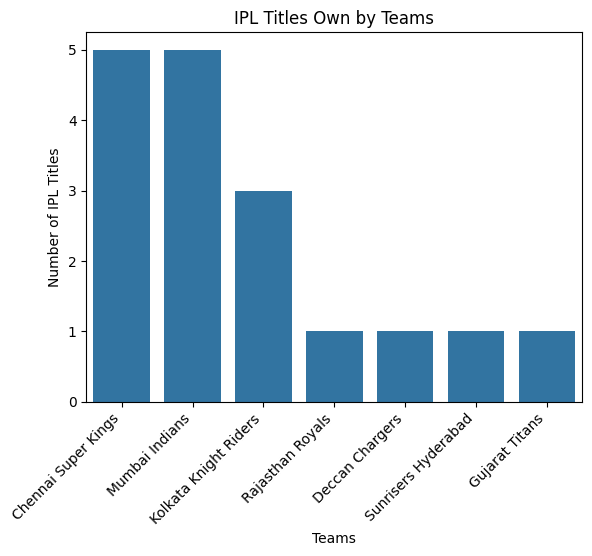

In [40]:
#Creating bar chart for IPL Title own by team
plt.Figure(figsize=(10,6))

sns.barplot(
    x=ipl_titles.index,
    y=ipl_titles.values,
)

plt.title("IPL Titles Own by Teams")
plt.xlabel('Teams')
plt.ylabel('Number of IPL Titles')
plt.xticks(rotation=45,ha='right')
plt.show()

### Insight

Mumbai Indians and Chennai Super Kings are the most successful franchises in IPL history, each winning five IPL titles. Kolkata Knight Riders rank third with three championships.

In [41]:
#Counting IPL Appearances by Team
final_appearances = pd.concat([
    final_matches['team1'],
    final_matches['team2']
]).value_counts()
final_appearances

Chennai Super Kings            10
Mumbai Indians                  6
Kolkata Knight Riders           4
Royal Challengers Bengaluru     3
Sunrisers Hyderabad             3
Rajasthan Royals                2
Gujarat Titans                  2
Delhi Capitals                  1
Deccan Chargers                 1
Punjab Kings                    1
Rising Pune Supergiants         1
Name: count, dtype: int64

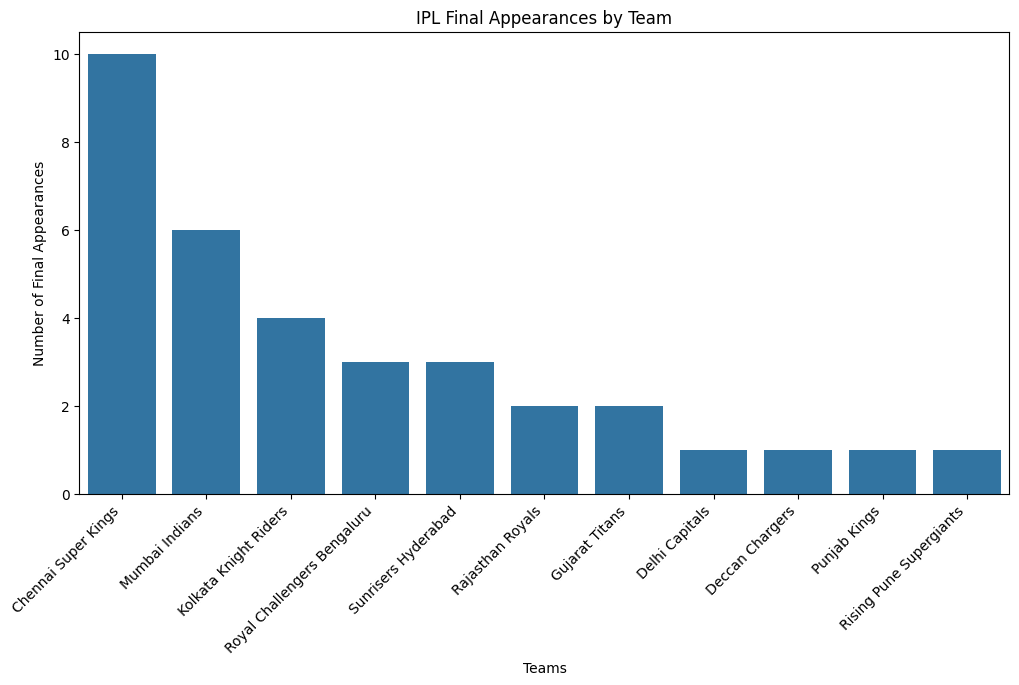

In [42]:
#creating bar chart for IPL Final appearances
plt.figure(figsize=(12,6))

sns.barplot(
    x=final_appearances.index,
    y=final_appearances.values,
)

plt.title("IPL Final Appearances by Team")
plt.xlabel('Teams')
plt.ylabel('Number of Final Appearances')
plt.xticks(rotation=45, ha='right')
plt.show()

### Insight

Chennai Super Kings have reached the IPL Final 10 times, the highest among all teams, highlighting their exceptional consistency. Mumbai Indians and Kolkata Knight Riders have also demonstrated strong performances through multiple Final appearances.

In [43]:
#Calculating Final Conversition Rate of Teams
final_conversion_rate = (ipl_titles / final_appearances).fillna(0)*100
final_conversion_rate.sort_values(ascending=False)

winner
Deccan Chargers                100.000000
Mumbai Indians                  83.333333
Kolkata Knight Riders           75.000000
Gujarat Titans                  50.000000
Chennai Super Kings             50.000000
Rajasthan Royals                50.000000
Sunrisers Hyderabad             33.333333
Delhi Capitals                   0.000000
Punjab Kings                     0.000000
Rising Pune Supergiants          0.000000
Royal Challengers Bengaluru      0.000000
Name: count, dtype: float64

### Insight

While Deccan Chargers achieved a 100% Final conversion rate, the result is based on only one Final appearance. Among teams with multiple Final appearances, Mumbai Indians have been the most efficient, winning 5 out of 6 Finals. Chennai Super Kings have reached the most Finals but converted 50% of those appearances into titles.

# Overall Conclusion

This IPL Data Analysis project explored team performance, player achievements, venue trends, and championship success across IPL seasons. The analysis highlights the dominance of Mumbai Indians and Chennai Super Kings, the consistency of Chennai Super Kings in reaching Finals, and the efficiency of Mumbai Indians in converting Final appearances into titles. The study also reveals the importance of chasing, the significance of major venues such as Wankhede Stadium, and the impact of star players such as AB de Villiers. Overall, the project demonstrates how data analysis can be used to uncover meaningful insights from sports data.

In [44]:
# Export cleaned dataset

df.to_csv(
    'matches_cleaned.csv',
    index=False
)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
